In [1]:
# IMPORT LIBRARIES

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df=pd.read_csv(r"C:\Users\paula\Downloads\processed_data.csv")

In [3]:
# DATASET INFORMATION


print(df.info())

print("\n")

print(df.describe())

print("\n")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

In [4]:
categorical_columns = [

    "traffic_density",
    "time_slot",
    "vehicle_type",
    "location_type",
    "weather_condition",
    "charging_priority"

]

In [5]:
# LABEL ENCODING


label_encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

print("Categorical columns encoded.")

Categorical columns encoded.


In [6]:
# TIME FEATURES
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour

df["weekday"] = df["timestamp"].dt.weekday

df["month"] = df["timestamp"].dt.month

print(df[["hour","weekday","month"]].head())

   hour  weekday  month
0     0        2      1
1     0        2      1
2     0        2      1
3     0        2      1
4     1        2      1


In [7]:
# FEATURE SELECTION

features = [

    "station_load",
    "traffic_density",
    "time_slot",
    "hour",
    "queue_length",
    "waiting_time",
    "charging_duration",
    "renewable_energy_ratio",
    "electricity_price",
    "vehicle_type",
    "location_type",
    "weather_condition",
    "charging_priority"

]

target = "charging_demand"

X = df[features]

y = df[target]

print(X.shape)

print(y.shape)

(8354, 13)
(8354,)


In [8]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=RANDOM_STATE

)
print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (6683, 13)
Testing Samples  : (1671, 13)


In [9]:
# XGBOOST MODEL
xgb_model = XGBRegressor(

    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=RANDOM_STATE

)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [10]:
# PREDICTIONS
y_pred = xgb_model.predict(X_test)

In [11]:
# MODEL EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

r2 = r2_score(y_test, y_pred)

print("="*40)
print("XGBOOST RESULTS")
print("="*40)

print(f"RMSE : {rmse:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.3f}")

XGBOOST RESULTS
RMSE : 2.960
MSE  : 8.759
MAE  : 2.545
MAPE : 7.00%
R²   : 0.989


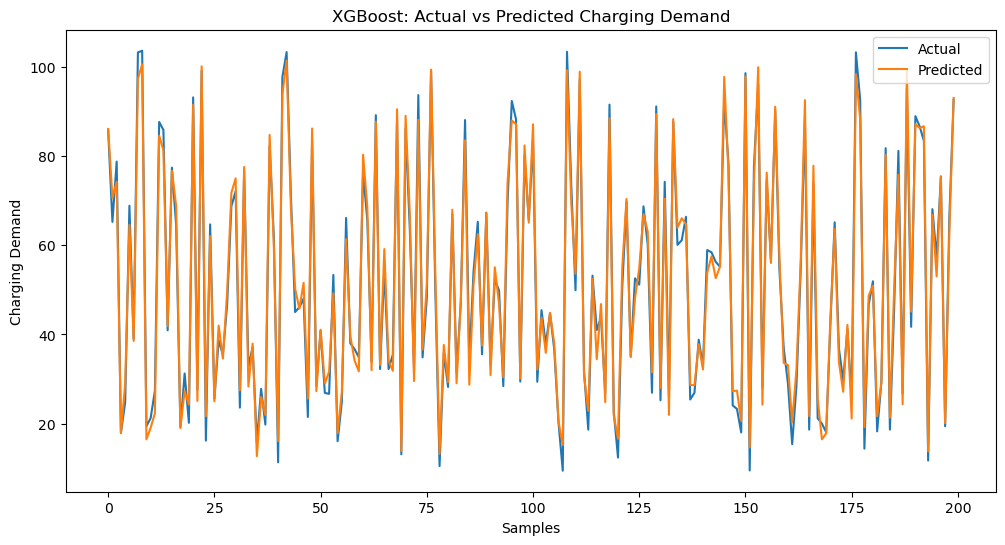

In [12]:
# ACTUAL VS PREDICTED
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")

plt.plot(y_pred[:200], label="Predicted")

plt.title("XGBoost: Actual vs Predicted Charging Demand")

plt.xlabel("Samples")

plt.ylabel("Charging Demand")

plt.legend()

plt.show()

In [13]:
# FEATURE IMPORTANCE
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                   Feature  Importance
1          traffic_density    0.639922
0             station_load    0.351677
2                time_slot    0.001648
4             queue_length    0.001224
7   renewable_energy_ratio    0.000778
8        electricity_price    0.000667
6        charging_duration    0.000634
10           location_type    0.000628
12       charging_priority    0.000587
5             waiting_time    0.000577
9             vehicle_type    0.000572
11       weather_condition    0.000562
3                     hour    0.000526


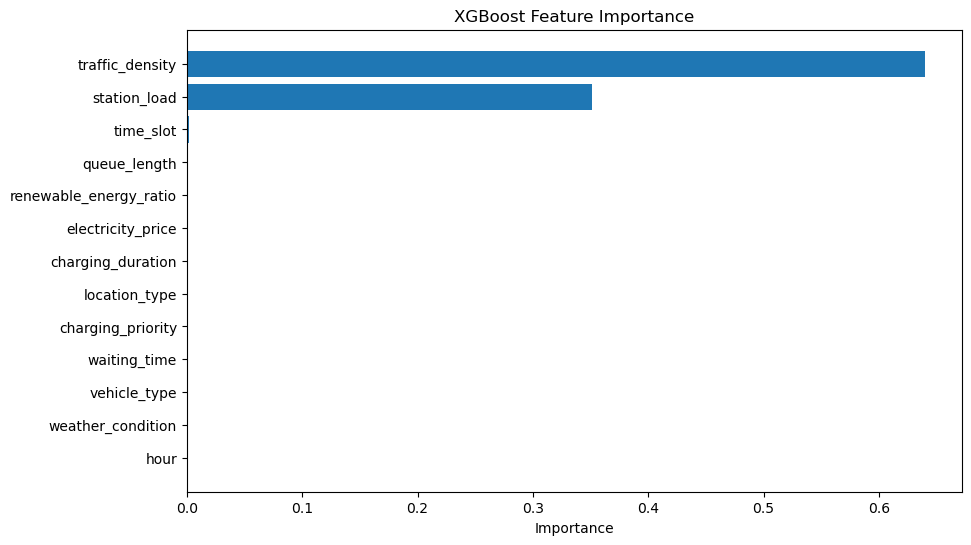

In [14]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [15]:
train_pred = xgb_model.predict(X_train)

In [16]:
train_r2 = r2_score(y_train, train_pred)

test_r2 = r2_score(y_test, y_pred)

print("Training R² :", train_r2)

print("Testing R²  :", test_r2)

Training R² : 0.9945157967810665
Testing R²  : 0.9886831312312271


In [17]:
train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Training RMSE :", train_rmse)

print("Testing RMSE  :", test_rmse)

Training RMSE : 2.0362601896498647
Testing RMSE  : 2.9595800124670797


In [18]:
from sklearn.model_selection import cross_val_score

In [19]:
scores = cross_val_score(

    xgb_model,
    X,
    y,
    cv=5,
    scoring="r2"

)

print("Cross Validation Scores")

print(scores)

print()

print("Mean R² :", scores.mean())

print("Standard Deviation :", scores.std())

Cross Validation Scores
[0.98802249 0.98822652 0.98759025 0.98808202 0.98858813]

Mean R² : 0.9881018827262148
Standard Deviation : 0.0003226263156249117


In [20]:
joblib.dump(
    xgb_model,
    "xgboost_model.pkl"
)

['xgboost_model.pkl']

In [21]:
joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

['label_encoders.pkl']

In [22]:
joblib.dump(
    features,
    "features.pkl"
)

['features.pkl']

In [23]:
loaded_model = joblib.load("xgboost_model.pkl")

loaded_features = joblib.load("features.pkl")

loaded_encoders = joblib.load("label_encoders.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [24]:
test_prediction = loaded_model.predict(X.head())

print(test_prediction)

[15.847702 19.387999 33.1572   21.153364 14.969022]


In [25]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

predictions.to_csv("xgboost_predictions.csv", index=False)

In [26]:
# RANDOM FOREST MODEL
rf_model = RandomForestRegressor(

    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1

)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [27]:
# PREDICTIONS
rf_pred = rf_model.predict(X_test)

In [28]:
# RANDOM FOREST RESULTS
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_mse = mean_squared_error(y_test, rf_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mape = np.mean(np.abs((y_test-rf_pred)/y_test))*100

rf_r2 = r2_score(y_test, rf_pred)

print("="*40)
print("RANDOM FOREST RESULTS")
print("="*40)

print(f"RMSE : {rf_rmse:.3f}")
print(f"MSE  : {rf_mse:.3f}")
print(f"MAE  : {rf_mae:.3f}")
print(f"MAPE : {rf_mape:.2f}%")
print(f"R²   : {rf_r2:.3f}")

RANDOM FOREST RESULTS
RMSE : 2.978
MSE  : 8.868
MAE  : 2.552
MAPE : 6.99%
R²   : 0.989


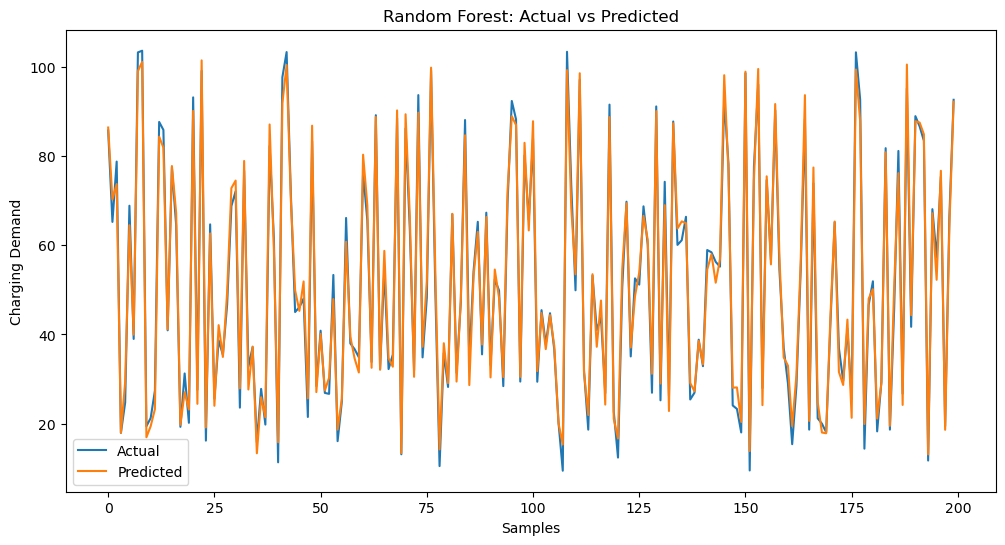

In [29]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")

plt.plot(rf_pred[:200], label="Predicted")

plt.title("Random Forest: Actual vs Predicted")

plt.xlabel("Samples")

plt.ylabel("Charging Demand")

plt.legend()

plt.show()

In [30]:
importance_rf = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance_rf = importance_rf.sort_values(

    by="Importance",

    ascending=False

)

print(importance_rf)

                   Feature  Importance
0             station_load    0.990911
7   renewable_energy_ratio    0.001682
8        electricity_price    0.001670
6        charging_duration    0.001636
5             waiting_time    0.001152
4             queue_length    0.000860
3                     hour    0.000777
11       weather_condition    0.000368
12       charging_priority    0.000366
9             vehicle_type    0.000361
10           location_type    0.000209
1          traffic_density    0.000006
2                time_slot    0.000003


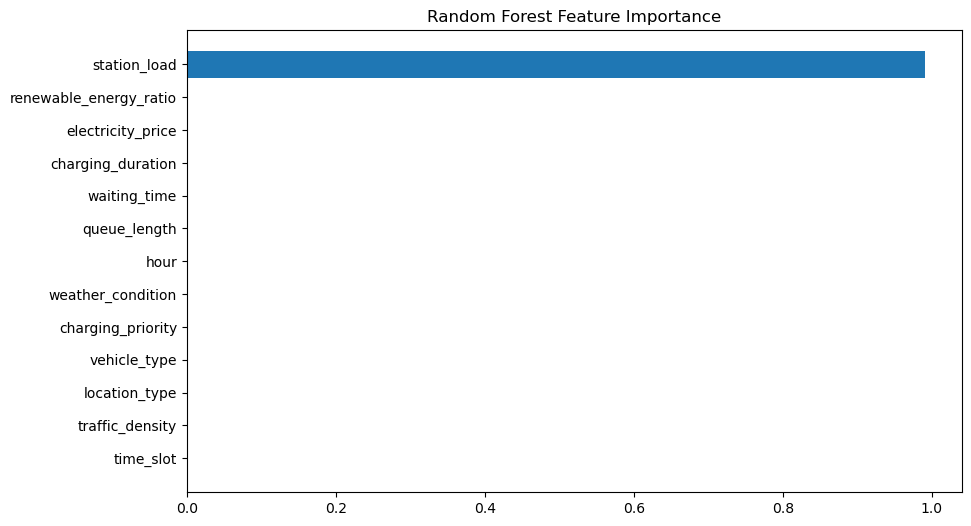

In [31]:
#graph
plt.figure(figsize=(10,6))

plt.barh(

    importance_rf["Feature"],

    importance_rf["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.show()

In [32]:
rf_train_pred = rf_model.predict(X_train)

In [33]:
train_r2_rf = r2_score(y_train, rf_train_pred)

test_r2_rf = r2_score(y_test, rf_pred)

print("Training R² :",train_r2_rf)

print("Testing R² :",test_r2_rf)

Training R² : 0.9983606657196439
Testing R² : 0.988542661054391


In [34]:
train_rmse_rf = np.sqrt(

    mean_squared_error(

        y_train,

        rf_train_pred

    )

)

test_rmse_rf = np.sqrt(

    mean_squared_error(

        y_test,

        rf_pred

    )

)

print("Training RMSE :",train_rmse_rf)

print("Testing RMSE :",test_rmse_rf)

Training RMSE : 1.113295006688217
Testing RMSE : 2.9778911997144095


In [35]:
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1

)

print("Cross Validation Scores")

print(rf_scores)

print()

print("Mean R² :",rf_scores.mean())

print("Std Dev :",rf_scores.std())

Cross Validation Scores
[0.98813913 0.98833762 0.98765261 0.98791971 0.9887104 ]

Mean R² : 0.9881518937408966
Std Dev : 0.00036049435543161843


In [36]:
joblib.dump(

    rf_model,
    "random_forest_model.pkl"

)
print("Random Forest saved successfully.")

Random Forest saved successfully.


In [37]:
loaded_rf = joblib.load(
    "random_forest_model.pkl"

)

loaded_rf.predict(

    X.head()

)

array([16.04644068, 19.30765593, 34.10764076, 19.03940975, 15.25453692])

In [38]:
comparison = pd.DataFrame({

    "Model":[

        "Random Forest",

        "XGBoost"

    ],

    "RMSE":[

        rf_rmse,
        rmse

    ],

    "MAE":[
        rf_mae,
        mae

    ],

    "MAPE":[

        rf_mape,
        mape

    ],

    "R²":[

        rf_r2,
        r2

    ]

})
comparison

,Model,RMSE,MAE,MAPE,R²
0,Random Forest,2.977891,2.551809,6.988016,0.988543
1,XGBoost,2.959580,2.544595,7.004458,0.988683


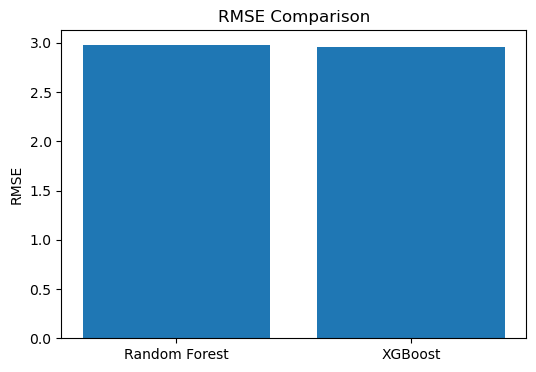

In [39]:
#comaprison graph
plt.figure(figsize=(6,4))

plt.bar(

    comparison["Model"],

    comparison["RMSE"]

)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.show()

In [40]:
# LOADING SAVED XGBOOST MODEL
import joblib

xgb_model = joblib.load("xgboost_model.pkl")

print("XGBoost model loaded successfully!")

XGBoost model loaded successfully!


In [41]:
# PREDICT WHOLE DATASET
df["Predicted_Demand"] = xgb_model.predict(X)

df[["charging_demand","Predicted_Demand"]].head()

,charging_demand,Predicted_Demand
0,17.242398,15.847702
1,18.324933,19.387999
2,36.028168,33.157200
3,17.146935,21.153364
4,14.577768,14.969022


In [42]:
station_results = df.groupby("station_id").agg({

    "Predicted_Demand":"mean",

    "station_load":"mean",

    "traffic_density":"mean",

    "queue_length":"mean",

    "waiting_time":"mean",

    "renewable_energy_ratio":"mean"

}).reset_index()

station_results.head()

,station_id,Predicted_Demand,station_load,traffic_density,queue_length,waiting_time,renewable_energy_ratio
0,ST001,54.377113,54.509444,0.891648,4.519187,9.492099,0.360856
1,ST002,54.509132,54.533898,0.869347,4.776382,9.376884,0.356440
2,ST003,54.984737,54.921031,0.828306,4.596288,9.640371,0.360942
3,ST004,54.428234,54.490898,0.856790,4.533333,10.066667,0.355779
4,ST005,52.931824,52.922748,0.908676,4.607306,9.296804,0.364283


In [43]:
print(station_results.shape)

(20, 7)


In [44]:
station_results

,station_id,Predicted_Demand,station_load,traffic_density,queue_length,waiting_time,renewable_energy_ratio
0,ST001,54.377113,54.509444,0.891648,4.519187,9.492099,0.360856
1,ST002,54.509132,54.533898,0.869347,4.776382,9.376884,0.356440
2,ST003,54.984737,54.921031,0.828306,4.596288,9.640371,0.360942
3,ST004,54.428234,54.490898,0.856790,4.533333,10.066667,0.355779
4,ST005,52.931824,52.922748,0.908676,4.607306,9.296804,0.364283
5,ST006,52.070587,52.082804,0.874092,4.624697,9.585956,0.347753
6,ST007,54.816536,54.852988,0.843990,4.255754,9.424552,0.352557
7,ST008,53.101307,53.174558,0.842500,4.697500,9.302500,0.341873
8,ST009,52.493629,52.533607,0.832134,4.623501,9.858513,0.345636
9,ST010,53.411388,53.418027,0.889163,4.596059,9.497537,0.353092


In [46]:
# PEAK DEMAND PER STATION
peak_demand = df.groupby("station_id").agg({

    "Predicted_Demand":"max",

    "queue_length":"max",

    "waiting_time":"max",

    "station_load":"max",

    "traffic_density":"mean",

    "renewable_energy_ratio":"mean"

}).reset_index()

peak_demand.head()

,station_id,Predicted_Demand,queue_length,waiting_time,station_load,traffic_density,renewable_energy_ratio
0,ST001,102.609398,13,27,100.0,0.891648,0.360856
1,ST002,101.982651,13,23,100.0,0.869347,0.356440
2,ST003,102.719040,12,24,100.0,0.828306,0.360942
3,ST004,101.647072,13,23,100.0,0.856790,0.355779
4,ST005,102.457687,14,23,100.0,0.908676,0.364283


In [47]:
station_results = station_results.merge(

    peak_demand,

    on="station_id",

    suffixes=("_Avg","_Peak")

)

station_results.head()

,station_id,Predicted_Demand_Avg,station_load_Avg,traffic_density_Avg,queue_length_Avg,waiting_time_Avg,renewable_energy_ratio_Avg,Predicted_Demand_Peak,queue_length_Peak,waiting_time_Peak,station_load_Peak,traffic_density_Peak,renewable_energy_ratio_Peak
0,ST001,54.377113,54.509444,0.891648,4.519187,9.492099,0.360856,102.609398,13,27,100.0,0.891648,0.360856
1,ST002,54.509132,54.533898,0.869347,4.776382,9.376884,0.356440,101.982651,13,23,100.0,0.869347,0.356440
2,ST003,54.984737,54.921031,0.828306,4.596288,9.640371,0.360942,102.719040,12,24,100.0,0.828306,0.360942
3,ST004,54.428234,54.490898,0.856790,4.533333,10.066667,0.355779,101.647072,13,23,100.0,0.856790,0.355779
4,ST005,52.931824,52.922748,0.908676,4.607306,9.296804,0.364283,102.457687,14,23,100.0,0.908676,0.364283


In [49]:
sessions_per_charger = 15

In [50]:
import numpy as np

station_results["Recommended_Chargers"] = np.ceil(

    station_results["Predicted_Demand_Peak"]

    / sessions_per_charger

).astype(int)

In [51]:
station_results["Recommended_Chargers"] = station_results[
    "Recommended_Chargers"
].clip(lower=2)

In [53]:
top = len(station_results)

station_results["Priority"] = "Low"

station_results.loc[:int(top*0.30)-1,"Priority"] = "High"

station_results.loc[
    int(top*0.30):int(top*0.70)-1,
    "Priority"
] = "Medium"

In [55]:
print(station_results.columns.tolist())

['station_id', 'Predicted_Demand_Avg', 'station_load_Avg', 'traffic_density_Avg', 'queue_length_Avg', 'waiting_time_Avg', 'renewable_energy_ratio_Avg', 'Predicted_Demand_Peak', 'queue_length_Peak', 'waiting_time_Peak', 'station_load_Peak', 'traffic_density_Peak', 'renewable_energy_ratio_Peak', 'Recommended_Chargers', 'Priority']


In [56]:
# RECREATE SUITABILITY INDEX
station_results["Suitability_Index"] = (

    0.35 * station_results["Predicted_Demand_Avg"] +
    0.20 * station_results["station_load_Avg"] +
    0.15 * station_results["traffic_density_Avg"] +
    0.10 * station_results["queue_length_Avg"] +
    0.10 * station_results["waiting_time_Avg"] +
    0.10 * station_results["renewable_energy_ratio_Avg"]

)

In [57]:
station_results = station_results.sort_values(
    by="Suitability_Index",
    ascending=False
).reset_index(drop=True)

In [59]:
importance

,Feature,Importance
1,traffic_density,0.639922
0,station_load,0.351677
2,time_slot,0.001648
4,queue_length,0.001224
7,renewable_energy_ratio,0.000778
8,electricity_price,0.000667
6,charging_duration,0.000634
10,location_type,0.000628
12,charging_priority,0.000587
5,waiting_time,0.000577


In [60]:
0.35 * station_results["Predicted_Demand_Peak"]

0     35.603790
1     35.951664
2     36.208370
3     35.576473
4     35.693928
5     35.913288
6     36.038826
7     35.847019
8     35.515545
9     35.757919
10    35.860191
11    35.792057
12    35.454987
13    35.904736
14    35.941059
15    35.858772
16    35.825806
17    35.831284
18    35.970268
19    35.879383
Name: Predicted_Demand_Peak, dtype: float32

In [61]:
station_results["Suitability_Index"] = (
    0.35 * station_results["Predicted_Demand_Peak"] +
    0.20 * station_results["station_load_Avg"] +
    0.15 * station_results["traffic_density_Avg"] +
    0.10 * station_results["queue_length_Avg"] +
    0.10 * station_results["waiting_time_Avg"] +
    0.10 * station_results["renewable_energy_ratio_Avg"]
)

In [62]:
avg_duration = df["charging_duration"].mean()

print("Average Charging Duration (hours):", avg_duration)

Average Charging Duration (hours): 178.7003758781695


In [63]:
station_operating_hours = 24

sessions_per_charger = station_operating_hours / avg_duration

print("Sessions per Charger:", sessions_per_charger)

Sessions per Charger: 0.13430301912941808


In [64]:
sessions_per_charger = int(sessions_per_charger)

print("Using", sessions_per_charger, "sessions per charger")

Using 0 sessions per charger


In [65]:
print(df["charging_duration"].describe())

count    8354.000000
mean      178.700376
std       149.120567
min        10.000000
25%        64.118008
50%       133.700252
75%       247.946169
max       776.551110
Name: charging_duration, dtype: float64


In [66]:
avg_duration_hours = df["charging_duration"].mean() / 60

print("Average Charging Duration (hours):", avg_duration_hours)

Average Charging Duration (hours): 2.9783395979694918


In [67]:
station_operating_hours = 24

sessions_per_charger = station_operating_hours / avg_duration_hours

print("Sessions per Charger:", sessions_per_charger)

Sessions per Charger: 8.058181147765085


In [68]:
sessions_per_charger = int(np.floor(sessions_per_charger))

print("Using", sessions_per_charger, "sessions per charger")

Using 8 sessions per charger


In [69]:
station_results["Recommended_Chargers"] = np.ceil(
    station_results["Predicted_Demand_Peak"] / sessions_per_charger
).astype(int)

In [70]:
station_results["Recommended_Chargers"] = (
    station_results["Recommended_Chargers"]
    .clip(lower=2, upper=12)
)

In [73]:
top10.to_csv("Top10_EV_Charging_Stations.csv", index=False)

final_results.to_csv("Final_EV_Charging_Recommendations.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


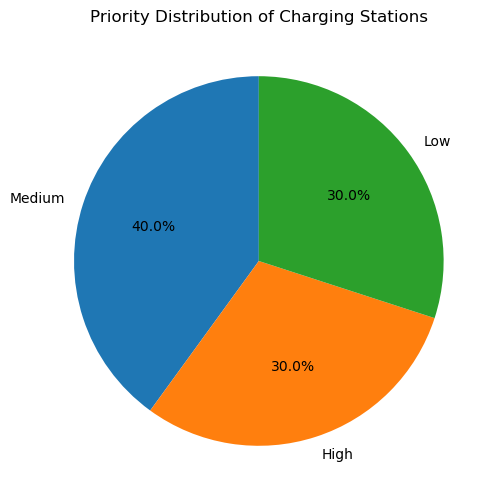

In [88]:
#priority distribution
priority_counts = final_results["Priority"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    priority_counts,
    labels=priority_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Priority Distribution of Charging Stations")

plt.show()

In [91]:
print(station_results.columns.tolist())

['station_id', 'Predicted_Demand', 'station_load', 'traffic_density', 'queue_length', 'waiting_time', 'renewable_energy_ratio', 'Sizing_Score', 'Recommended_Chargers']


In [92]:
print(station_results["Sizing_Score"].describe())

count    20.000000
mean      0.400809
std       0.282475
min       0.000000
25%       0.188200
50%       0.356256
75%       0.661892
max       1.000000
Name: Sizing_Score, dtype: float64


In [93]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
station_results["Normalized_Score"] = scaler.fit_transform(
    station_results[["Sizing_Score"]]
)

In [94]:
station_results["Recommended_Chargers"] = (
    3 + np.round(
        station_results["Normalized_Score"] * 7
    )
).astype(int)

In [96]:
print(station_results["Sizing_Score"].describe())

count    20.000000
mean      0.400809
std       0.282475
min       0.000000
25%       0.188200
50%       0.356256
75%       0.661892
max       1.000000
Name: Sizing_Score, dtype: float64


In [97]:
print(station_results["Sizing_Score"].describe())

count    20.000000
mean      0.400809
std       0.282475
min       0.000000
25%       0.188200
50%       0.356256
75%       0.661892
max       1.000000
Name: Sizing_Score, dtype: float64


In [98]:
station_results["Recommended_Chargers"] = (
    np.floor(2 + station_results["Sizing_Score"] * 10)
).astype(int)

In [102]:
station_results["Recommended_Chargers"] = (
    np.floor(2 + station_results["Sizing_Score"] * 10)
).astype(int)

In [103]:
print(station_results[[
    "station_id",
    "Sizing_Score",
    "Recommended_Chargers"
]].sort_values("Recommended_Chargers", ascending=False))

   station_id  Sizing_Score  Recommended_Chargers
11      ST012      1.000000                    12
2       ST003      0.800861                    10
1       ST002      0.700231                     9
3       ST004      0.710697                     9
6       ST007      0.703230                     9
0       ST001      0.649112                     8
12      ST013      0.485541                     6
9       ST010      0.453908                     6
7       ST008      0.384281                     5
4       ST005      0.336220                     5
13      ST014      0.322813                     5
14      ST015      0.376293                     5
8       ST009      0.292858                     4
15      ST016      0.224335                     4
5       ST006      0.179801                     3
16      ST017      0.191000                     3
17      ST018      0.142044                     3
18      ST019      0.053532                     2
10      ST011      0.000000                     2


In [104]:
avg_duration_hours = df["charging_duration"].mean() / 60

print("Average Charging Duration (hours):", avg_duration_hours)

Average Charging Duration (hours): 2.9783395979694918
